Environment Ready

EXPERIMENT 1: CICIDS/Kaggle Malicious vs. Benign Detection
Monday-WorkingHours.pcap_ISCX.csv (529918, 79)
Label
BENIGN    529918
Name: count, dtype: int64
--------------------------------------------------
Tuesday-WorkingHours.pcap_ISCX.csv (445909, 79)
Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64
--------------------------------------------------
Wednesday-workingHours.pcap_ISCX.csv (692703, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
--------------------------------------------------
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv (225745, 79)
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64
--------------------------------------------------
Combined dataset shape: (1894275, 79)

Combined labels:
Label
BENIGN              1499741
DoS Hulk      

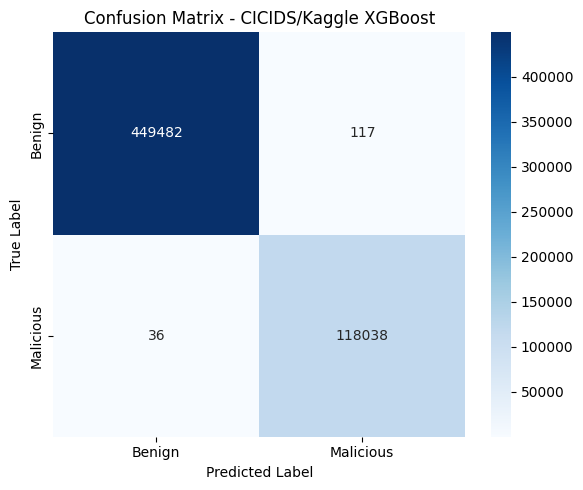

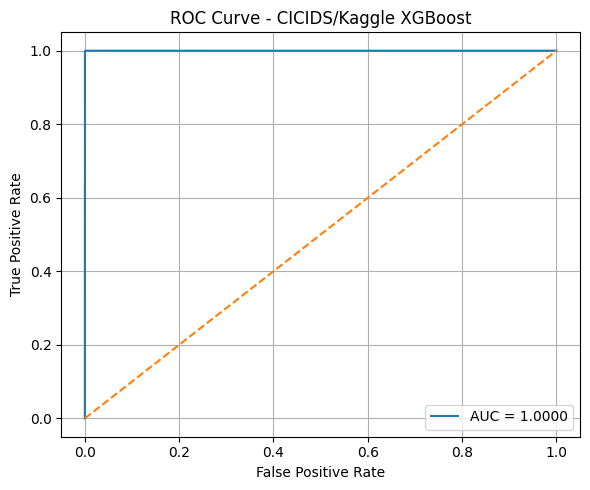

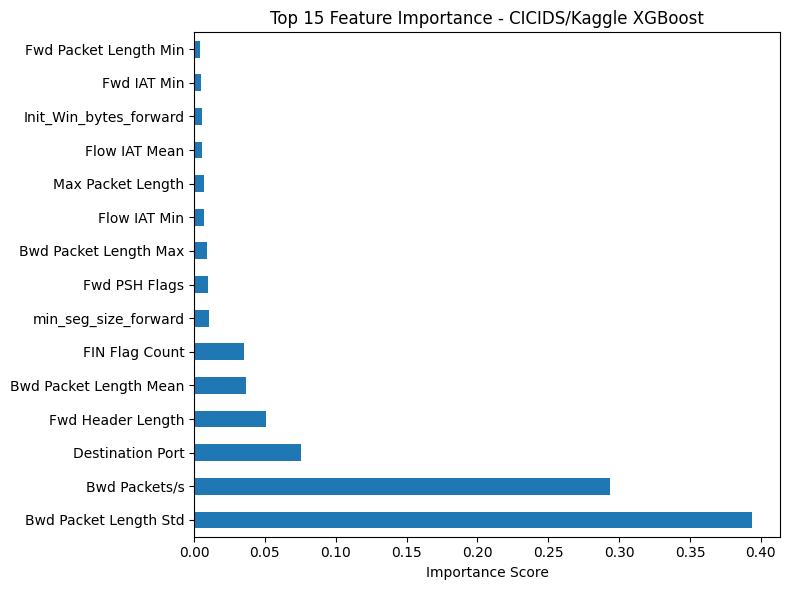


=== SYNTHETIC PERTURBATION STRESS TEST: CICIDS/Kaggle ===
              precision    recall  f1-score   support

      Benign       0.79      0.96      0.87    449599
   Malicious       0.15      0.03      0.04    118074

    accuracy                           0.77    567673
   macro avg       0.47      0.49      0.46    567673
weighted avg       0.66      0.77      0.70    567673

Perturbed Accuracy: 0.7667
Perturbed F1 Score: 0.0430
Perturbed ROC-AUC: 0.6717

Synthetic Perturbation Confusion Matrix Values:
TN: 432264, FP: 17335, FN: 115097, TP: 2977


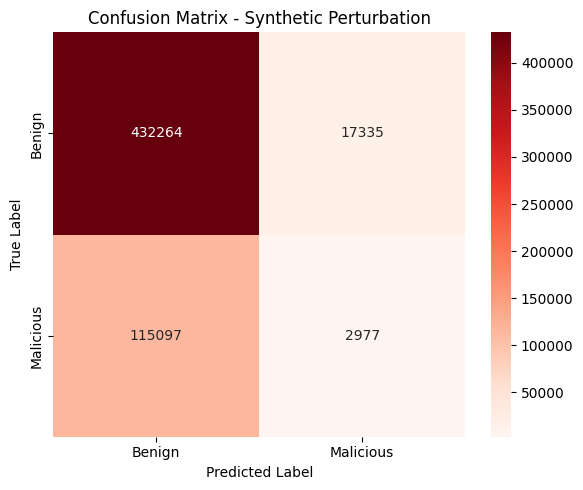

In [ ]:
# TLS Fingerprinting for Malicious vs. Benign Traffic
# Course: CPRE-5600
# Group Members: Mahesh Babu Tasil, Vijaysimha Bandaru, Sai Soma
# Final Project Code
#
# Experiment 1:
#   CICIDS/Kaggle dataset for malicious vs. benign classification
#
# Experiment 2:
#   CESNET-TLS22 real TLS metadata proof-of-concept classification
#
# Notes:
#   - CICIDS/Kaggle dataset has malicious/benign labels but no TLS fields.
#   - CESNET-TLS22 has real TLS traffic metadata but service/application labels,
#     not verified malicious/benign labels.


# Install packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost cesnet-datazoo

# 1. Imports
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("Environment Ready\n")

os.makedirs("outputs", exist_ok=True)

# EXPERIMENT 1: CICIDS / Kaggle Malicious vs. Benign Detection

print("=" * 75)
print("EXPERIMENT 1: CICIDS/Kaggle Malicious vs. Benign Detection")
print("=" * 75)

files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

df_list = []

for file in files:
    if os.path.exists(file):
        temp = pd.read_csv(file)
        temp.columns = temp.columns.str.strip()
        print(file, temp.shape)
        print(temp["Label"].astype(str).str.strip().value_counts().head(10))
        print("-" * 50)
        df_list.append(temp)
    else:
        print(f"Missing file: {file}")

if len(df_list) == 0:
    raise FileNotFoundError(
        "No CICIDS/Kaggle CSV files found. Upload the required CSV files before running Experiment 1."
    )

df = pd.concat(df_list, ignore_index=True)
df.columns = df.columns.str.strip()

print("Combined dataset shape:", df.shape)
print("\nCombined labels:")
print(df["Label"].astype(str).str.strip().value_counts())

# Label cleaning
df["Label"] = df["Label"].astype(str).str.strip()
df["label"] = df["Label"].apply(lambda x: 0 if x.upper() == "BENIGN" else 1)
df.drop(columns=["Label"], inplace=True)

# Missing/infinite cleaning
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("\nAfter cleaning shape:", df.shape)
print("\nBinary label distribution:")
print(df["label"].value_counts())

# Check TLS-specific fields
tls_keywords = [
    "tls", "ssl", "ja3", "ja3s", "cipher", "sni",
    "server_name", "alpn", "certificate", "cert", "handshake"
]

tls_like_columns = [
    col for col in df.columns
    if any(keyword in str(col).lower() for keyword in tls_keywords)
]

print("\nTLS-like columns found in CICIDS/Kaggle dataset:")
print(tls_like_columns)

if len(tls_like_columns) == 0:
    print("\nWARNING: No TLS-specific fields were found in the CICIDS/Kaggle CSV files.")
    print("Experiment 1 uses flow-level metadata, not full TLS handshake metadata.")


# Feature selection
X = df.select_dtypes(include=[np.number]).drop("label", axis=1)
y = df["label"]

print("\nFeature shape BEFORE removing selected leakage-prone columns:", X.shape)

leaky_cols = [
    "Flow Bytes/s",
    "Flow Packets/s",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "Average Packet Size"
]

X = X.drop(columns=[col for col in leaky_cols if col in X.columns])

print("Feature shape AFTER removing selected leakage-prone columns:", X.shape)

# train/test split and scaling
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print("\nTrain shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())


# Model training
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1
    )
}

results = {}

print("\n=== CICIDS/Kaggle MODEL PERFORMANCE ===")

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train_scaled, y_train)

    y_pred_model = model.predict(X_test_scaled)
    y_prob_model = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred_model)
    f1 = f1_score(y_test, y_pred_model)
    auc = roc_auc_score(y_test, y_prob_model)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "ROC-AUC": auc
    }

    print(f"\n{name}")
    print(classification_report(y_test, y_pred_model, target_names=["Benign", "Malicious"]))
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {auc:.4f}")

results_df = pd.DataFrame(results).T
print("\n=== CICIDS/Kaggle MODEL COMPARISON TABLE ===")
print(results_df.round(4))

# Final model
best_model = models["XGBoost"]

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

final_acc = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)
final_auc = roc_auc_score(y_test, y_prob)

print("\n=== FINAL CICIDS/Kaggle MODEL: XGBoost ===")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malicious"]))
print(f"Accuracy: {final_acc:.4f}")
print(f"F1 Score: {final_f1:.4f}")
print(f"ROC-AUC: {final_auc:.4f}")

# Confusion matrix interpretation
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n=== CICIDS/Kaggle Confusion Matrix Values ===")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"]
)
plt.title("Confusion Matrix - CICIDS/Kaggle XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_cicids.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {final_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CICIDS/Kaggle XGBoost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/roc_curve_cicids.png", dpi=300, bbox_inches="tight")
plt.show()

# Feature importance
importances = pd.Series(best_model.feature_importances_, index=X.columns)

plt.figure(figsize=(8, 6))
importances.nlargest(15).plot(kind="barh")
plt.title("Top 15 Feature Importance - CICIDS/Kaggle XGBoost")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("outputs/feature_importance_cicids.png", dpi=300, bbox_inches="tight")
plt.show()

# Synthetic perturbation stress test
print("\n=== SYNTHETIC PERTURBATION STRESS TEST: CICIDS/Kaggle ===")

X_perturbed = X_test_scaled.copy()

np.random.seed(42)
noise = np.random.normal(loc=0, scale=0.35, size=X_perturbed.shape)
X_perturbed = X_perturbed + noise

y_pred_perturbed = best_model.predict(X_perturbed)
y_prob_perturbed = best_model.predict_proba(X_perturbed)[:, 1]

perturb_acc = accuracy_score(y_test, y_pred_perturbed)
perturb_f1 = f1_score(y_test, y_pred_perturbed)
perturb_auc = roc_auc_score(y_test, y_prob_perturbed)

print(classification_report(y_test, y_pred_perturbed, target_names=["Benign", "Malicious"]))
print(f"Perturbed Accuracy: {perturb_acc:.4f}")
print(f"Perturbed F1 Score: {perturb_f1:.4f}")
print(f"Perturbed ROC-AUC: {perturb_auc:.4f}")

cm_perturbed = confusion_matrix(y_test, y_pred_perturbed)
tn_p, fp_p, fn_p, tp_p = cm_perturbed.ravel()

print("\nSynthetic Perturbation Confusion Matrix Values:")
print(f"TN: {tn_p}, FP: {fp_p}, FN: {fn_p}, TP: {tp_p}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_perturbed,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"]
)
plt.title("Confusion Matrix - Synthetic Perturbation")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_perturbation_cicids.png", dpi=300, bbox_inches="tight")
plt.show()


In [1]:
# EXPERIMENT 2: CESNET-TLS22 Real TLS Metadata Proof-of-Concept

print("\n" + "=" * 75)
print("EXPERIMENT 2: CESNET-TLS22 Real TLS Metadata Proof-of-Concept")
print("=" * 75)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cesnet_datazoo.datasets import CESNET_TLS22
from cesnet_datazoo.config import DatasetConfig, AppSelection

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

os.makedirs("outputs", exist_ok=True)

# 1. Load CESNET-TLS22
dataset = CESNET_TLS22("data/CESNET-TLS22/", size="XS")

train_period = getattr(dataset, "default_train_period_name", "W-2021-40")
test_period = getattr(dataset, "default_test_period_name", "W-2021-41")

print("Train period:", train_period)
print("Test period:", test_period)

dataset_config = DatasetConfig(
    dataset=dataset,
    apps_selection=AppSelection.ALL_KNOWN,
    train_period_name=train_period,
    test_period_name=test_period,
)

dataset.set_dataset_config_and_initialize(dataset_config)

train_df = dataset.get_train_df()
test_df = dataset.get_test_df()

train_df = train_df.sample(n=min(30000, len(train_df)), random_state=42)
test_df = test_df.sample(n=min(15000, len(test_df)), random_state=42)

print("Sampled CESNET train shape:", train_df.shape)
print("Sampled CESNET test shape:", test_df.shape)

print("\nFirst 30 columns:")
print(train_df.columns.tolist()[:30])


EXPERIMENT 2: CESNET-TLS22 Real TLS Metadata Proof-of-Concept
Train period: W-2021-40
Test period: W-2021-41


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loading data from dataloader


  0%|          | 0/21577 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 21577/21577 [00:53<00:00, 403.82it/s]


Loading data from dataloader


100%|██████████| 2355/2355 [00:23<00:00, 100.92it/s]


Sampled CESNET train shape: (30000, 10)
Sampled CESNET test shape: (15000, 10)

First 30 columns:
['PPI', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV', 'DURATION', 'PPI_LEN', 'PPI_ROUNDTRIPS', 'PPI_DURATION', 'APP']


In [2]:
print("\n=== CESNET-TLS22 Feature and Label Preparation ===")

label_col = "APP"

print("\nAPP label distribution:")
print(train_df[label_col].value_counts().head(20))

majority_app = train_df[label_col].value_counts().index[0]

train_df["binary_label"] = (train_df[label_col] != majority_app).astype(int)
test_df["binary_label"] = (test_df[label_col] != majority_app).astype(int)

print("\nMajority APP used as Class 0:", majority_app)
print("Class 0 = Majority APP")
print("Class 1 = Other APPs")

print("\nBinary train distribution:")
print(train_df["binary_label"].value_counts())

print("\nBinary test distribution:")
print(test_df["binary_label"].value_counts())

# Feature preparation

feature_cols = [
    "BYTES",
    "BYTES_REV",
    "PACKETS",
    "PACKETS_REV",
    "DURATION",
    "PPI_LEN",
    "PPI_ROUNDTRIPS",
    "PPI_DURATION"
]

feature_cols = [col for col in feature_cols if col in train_df.columns]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df["binary_label"]
y_test = test_df["binary_label"]

X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

print("\nSelected CESNET features:")
print(feature_cols)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


=== CESNET-TLS22 Feature and Label Preparation ===

APP label distribution:
APP
124    1027
142    1012
110    1006
25      951
131     894
105     858
64      778
77      731
109     725
103     695
157     679
18      676
147     672
161     671
88      640
92      634
138     564
151     545
164     516
149     473
Name: count, dtype: int64

Majority APP used as Class 0: 124
Class 0 = Majority APP
Class 1 = Other APPs

Binary train distribution:
binary_label
1    28973
0     1027
Name: count, dtype: int64

Binary test distribution:
binary_label
1    14474
0      526
Name: count, dtype: int64

Selected CESNET features:
['BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV', 'DURATION', 'PPI_LEN', 'PPI_ROUNDTRIPS', 'PPI_DURATION']

X_train shape: (30000, 8)
X_test shape: (15000, 8)


In [3]:
# CESNET-TLS22 Model Training

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

os.makedirs("outputs", exist_ok=True)

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1
    )
}

results = {}

print("\n=== CESNET-TLS22 TLS TRAFFIC METADATA PROOF-OF-CONCEPT PERFORMANCE ===")

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "ROC-AUC": auc
    }

    print(f"\n{name}")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Majority APP", "Other APPs"]
    ))
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {auc:.4f}")

results_df = pd.DataFrame(results).T

print("\n=== CESNET-TLS22 MODEL COMPARISON TABLE ===")
print(results_df.round(4))


=== CESNET-TLS22 TLS TRAFFIC METADATA PROOF-OF-CONCEPT PERFORMANCE ===

Training Decision Tree...

Decision Tree
              precision    recall  f1-score   support

Majority APP       0.89      0.14      0.25       526
  Other APPs       0.97      1.00      0.98     14474

    accuracy                           0.97     15000
   macro avg       0.93      0.57      0.62     15000
weighted avg       0.97      0.97      0.96     15000

Accuracy: 0.9694
F1 Score: 0.9844
ROC-AUC: 0.7903

Training Random Forest...

Random Forest
              precision    recall  f1-score   support

Majority APP       0.95      0.34      0.50       526
  Other APPs       0.98      1.00      0.99     14474

    accuracy                           0.98     15000
   macro avg       0.96      0.67      0.74     15000
weighted avg       0.98      0.98      0.97     15000

Accuracy: 0.9762
F1 Score: 0.9878
ROC-AUC: 0.9032

Training XGBoost...

XGBoost
              precision    recall  f1-score   support

Major


=== FINAL CESNET-TLS22 MODEL: XGBoost ===
              precision    recall  f1-score   support

Majority APP       0.90      0.27      0.41       526
  Other APPs       0.97      1.00      0.99     14474

    accuracy                           0.97     15000
   macro avg       0.94      0.63      0.70     15000
weighted avg       0.97      0.97      0.97     15000

Accuracy: 0.9733
F1 Score: 0.9863
ROC-AUC: 0.8897


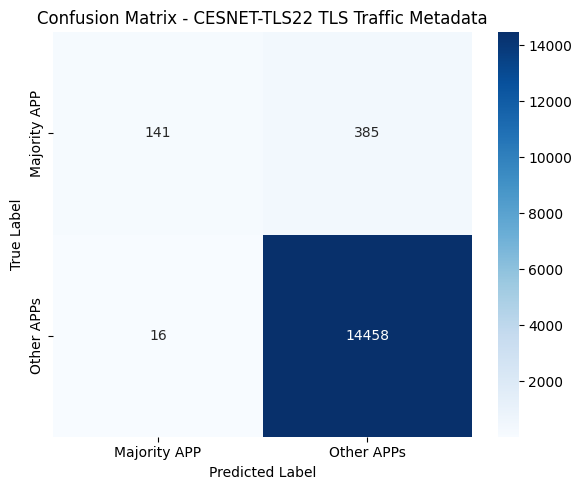

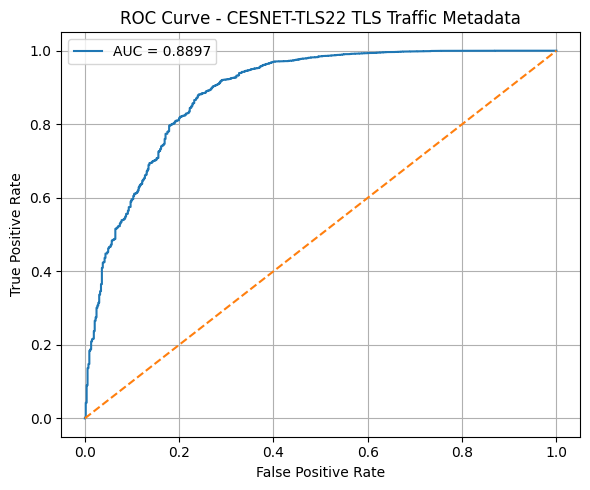

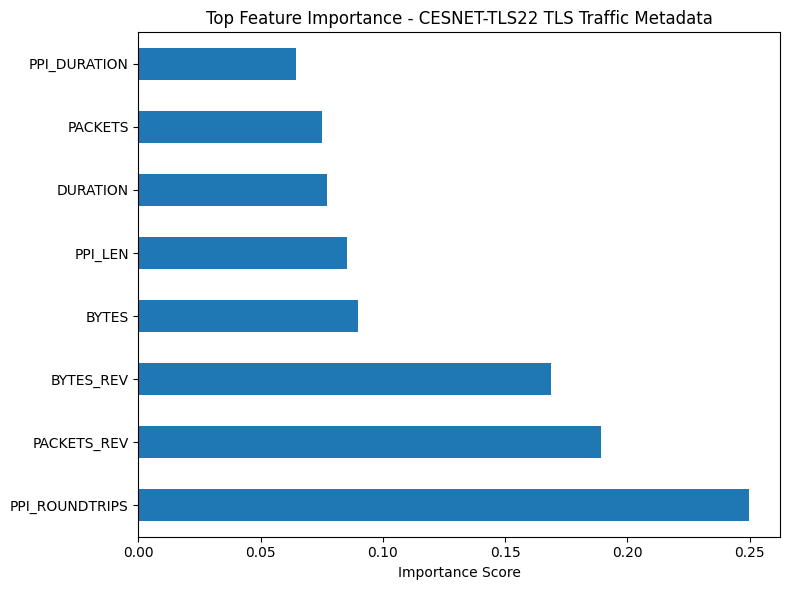


Saved CESNET output figures:
outputs/confusion_matrix_cesnet_tls.png
outputs/roc_curve_cesnet_tls.png
outputs/feature_importance_cesnet_tls.png


In [4]:
# CESNET-TLS22 Final Model Visualizations

best_model = models["XGBoost"]

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

cesnet_acc = accuracy_score(y_test, y_pred)
cesnet_f1 = f1_score(y_test, y_pred)
cesnet_auc = roc_auc_score(y_test, y_prob)

print("\n=== FINAL CESNET-TLS22 MODEL: XGBoost ===")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Majority APP", "Other APPs"]
))
print(f"Accuracy: {cesnet_acc:.4f}")
print(f"F1 Score: {cesnet_f1:.4f}")
print(f"ROC-AUC: {cesnet_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Majority APP", "Other APPs"],
    yticklabels=["Majority APP", "Other APPs"]
)
plt.title("Confusion Matrix - CESNET-TLS22 TLS Traffic Metadata")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_cesnet_tls.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {cesnet_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CESNET-TLS22 TLS Traffic Metadata")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/roc_curve_cesnet_tls.png", dpi=300, bbox_inches="tight")
plt.show()

# Feature Importance
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(8, 6))
importances.nlargest(15).plot(kind="barh")
plt.title("Top Feature Importance - CESNET-TLS22 TLS Traffic Metadata")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("outputs/feature_importance_cesnet_tls.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved CESNET output figures:")
print("outputs/confusion_matrix_cesnet_tls.png")
print("outputs/roc_curve_cesnet_tls.png")
print("outputs/feature_importance_cesnet_tls.png")

In [5]:
import shutil
from google.colab import files

# Create zip file from outputs folder
shutil.make_archive("project_output_images", "zip", "outputs")

# Download zip file
files.download("project_output_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>